In [ ]:
# Import libraries for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the merged dataset and parse the datetime index
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"From: {df.index.min().date()}")
print(f"To: {df.index.max().date()}")

Dataset loaded
Rows: 52461
Columns: 36
From: 2022-01-01
To: 2024-12-31


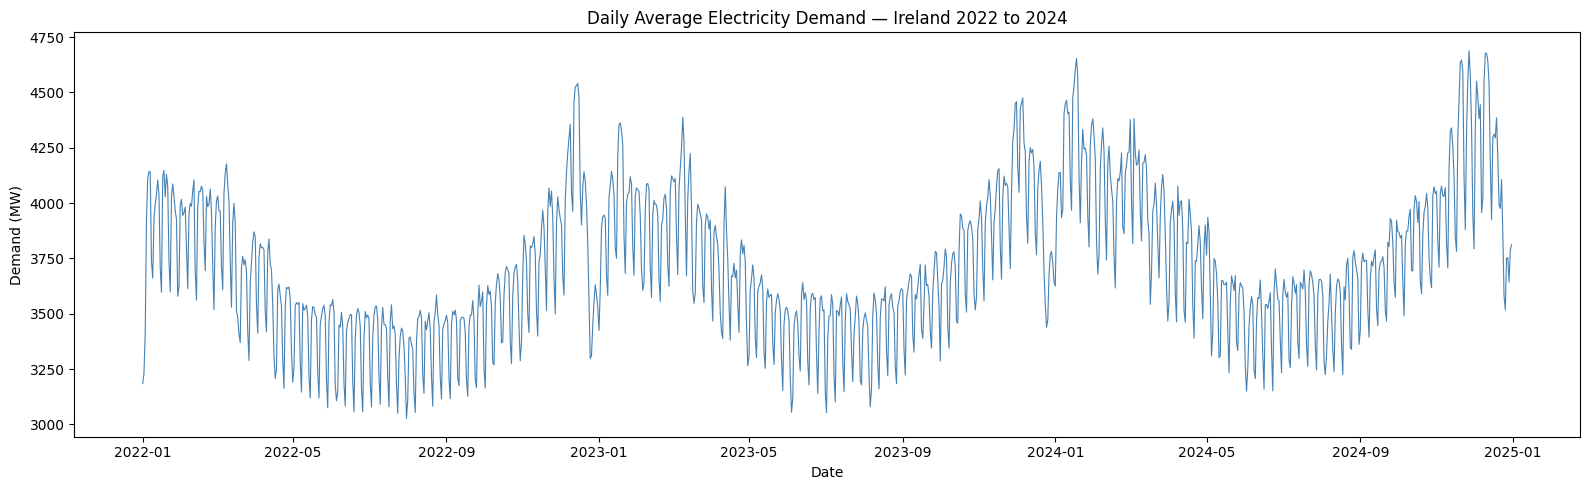

In [ ]:
# Chart 1 — Plotting daily average demand across full 3 years to see the overall trend and seasonal pattern
daily_demand = df['demand_mw'].resample('D').mean()

plt.figure(figsize=(16, 5))
plt.plot(daily_demand.index, daily_demand.values, color='steelblue', linewidth=0.8)
plt.title('Daily Average Electricity Demand — Ireland 2022 to 2024')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart1_overall_trend.png', dpi=150)
plt.show()


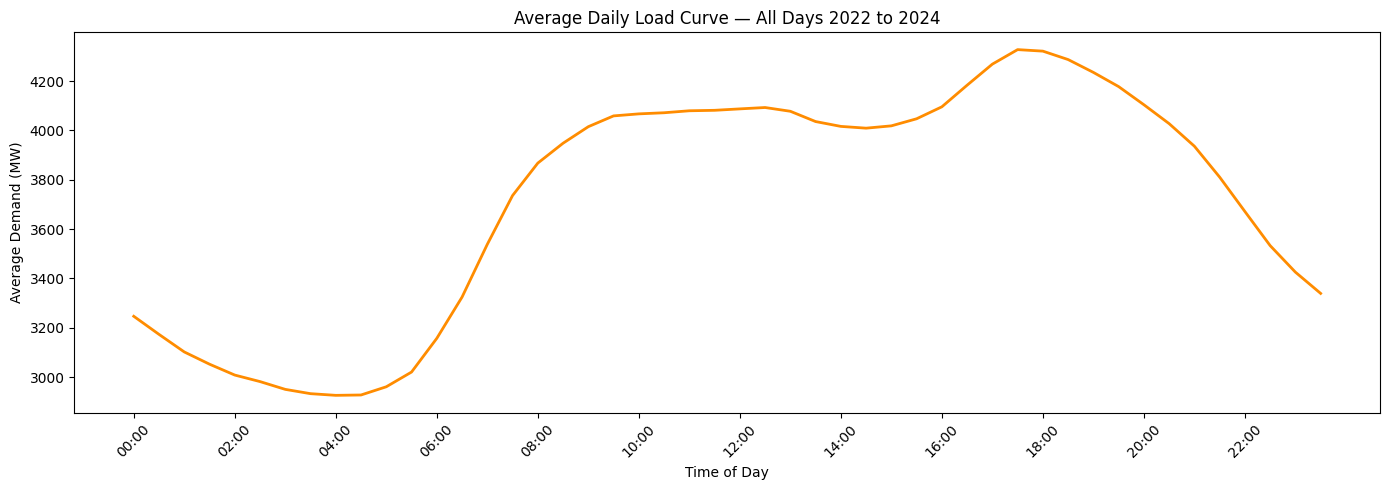

In [ ]:
# Chart 2 — Plotting average demand at each 30-minute slot of the day to see how demand rises and falls throughout a typical day
load_curve = df.groupby('halfhour_slot')['demand_mw'].mean()

time_labels = []
for slot in range(48):
    hour = slot // 2
    minute = '30' if slot % 2 == 1 else '00'
    time_labels.append(f"{hour:02d}:{minute}")

plt.figure(figsize=(14, 5))
plt.plot(load_curve.index, load_curve.values, color='darkorange', linewidth=2)
plt.xticks(ticks=range(0, 48, 4), labels=time_labels[::4], rotation=45)
plt.title('Average Daily Load Curve — All Days 2022 to 2024')
plt.xlabel('Time of Day')
plt.ylabel('Average Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart2_load_curve.png', dpi=150)
plt.show()


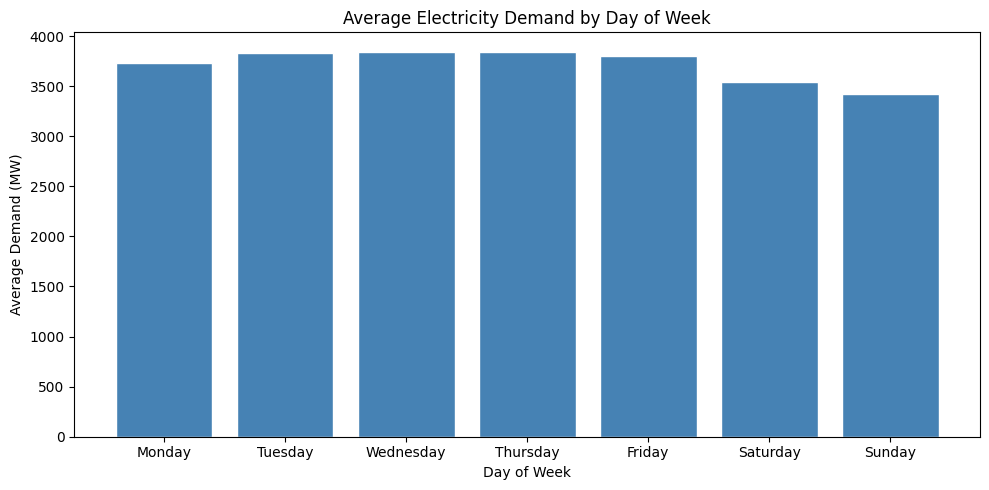

In [ ]:
# Chart 3 — Plotting average demand by day of week to see the difference between weekdays and weekends
day_names = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_demand = df.groupby('day_of_week')['demand_mw'].mean()

plt.figure(figsize=(10, 5))
plt.bar(day_names, dow_demand.values, color='steelblue', edgecolor='white')
plt.title('Average Electricity Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart3_demand_by_dow.png', dpi=150)
plt.show()


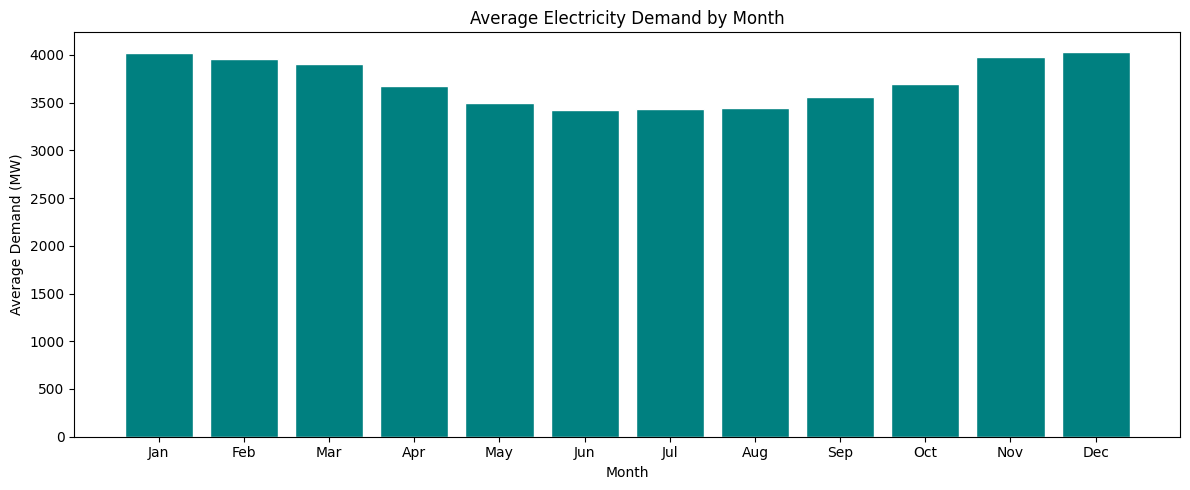

In [ ]:
# Chart 4 — Plotting average demand by month to confirm the seasonal pattern across the year
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_demand = df.groupby('month')['demand_mw'].mean()

plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_demand.values, color='teal', edgecolor='white')
plt.title('Average Electricity Demand by Month')
plt.xlabel('Month')
plt.ylabel('Average Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart4_demand_by_month.png', dpi=150)
plt.show()



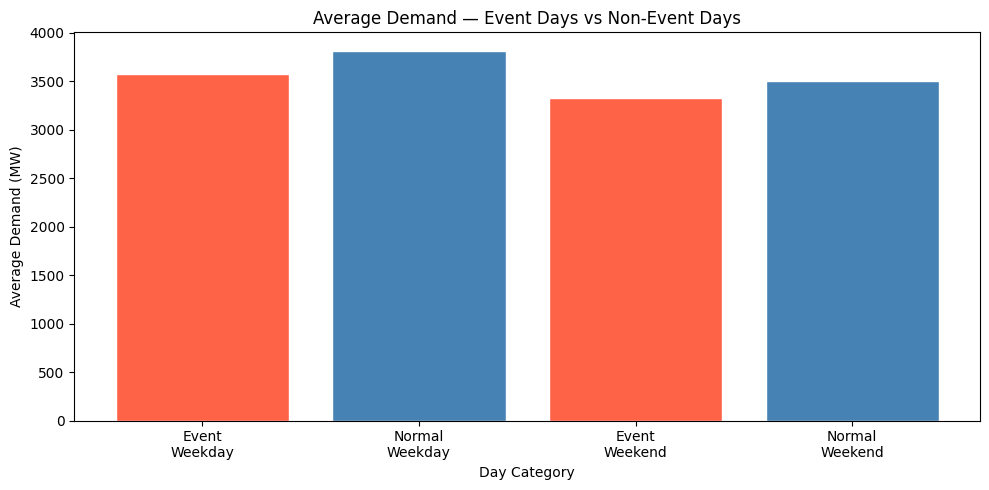

Event weekday demand:    3572.7 MW
Normal weekday demand:   3815.6 MW
Event weekend demand:    3332.0 MW
Normal weekend demand:   3505.8 MW


In [ ]:
# Chart 5 — Comparing average demand on event days vs normal days, split by weekday and weekend to isolate the event effect from the day-of-week effect
event_weekday    = df[(df['event_flag'] == 1) & (df['is_weekend'] == 0)]['demand_mw'].mean()
nonevent_weekday = df[(df['event_flag'] == 0) & (df['is_weekend'] == 0)]['demand_mw'].mean()
event_weekend    = df[(df['event_flag'] == 1) & (df['is_weekend'] == 1)]['demand_mw'].mean()
nonevent_weekend = df[(df['event_flag'] == 0) & (df['is_weekend'] == 1)]['demand_mw'].mean()

labels = ['Event\nWeekday', 'Normal\nWeekday',
          'Event\nWeekend', 'Normal\nWeekend']
values = [event_weekday, nonevent_weekday,
          event_weekend, nonevent_weekend]
colors = ['tomato', 'steelblue', 'tomato', 'steelblue']

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color=colors, edgecolor='white')
plt.title('Average Demand — Event Days vs Non-Event Days')
plt.xlabel('Day Category')
plt.ylabel('Average Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart5_event_vs_nonevent.png', dpi=150)
plt.show()

print(f"Event weekday demand:    {round(event_weekday, 1)} MW")
print(f"Normal weekday demand:   {round(nonevent_weekday, 1)} MW")
print(f"Event weekend demand:    {round(event_weekend, 1)} MW")
print(f"Normal weekend demand:   {round(nonevent_weekend, 1)} MW")

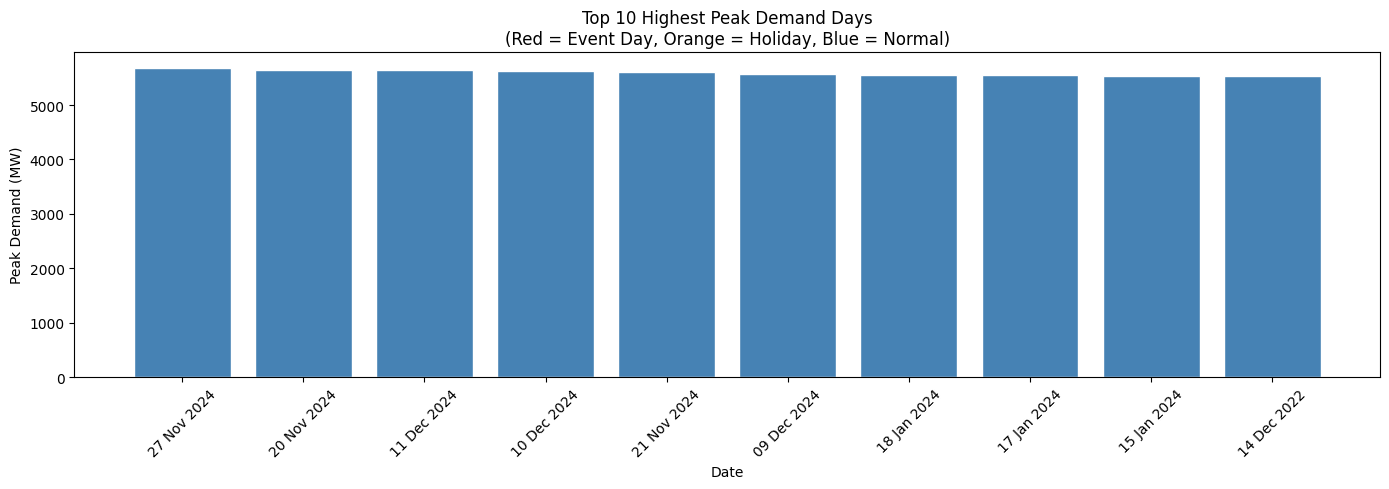

In [ ]:
# Chart 6 — Finding the 10 days with highest peak demand and checking whether they coincide with event days or public holidays
daily_peak = df.groupby(df.index.date)['demand_mw'].max()
top10 = daily_peak.sort_values(ascending=False).head(10)
top10.index = pd.to_datetime(top10.index)

bar_colors = []
for date in top10.index:
    day_rows = df[df.index.date == date.date()]
    if day_rows['event_flag'].max() == 1:
        bar_colors.append('tomato')
    elif day_rows['is_public_holiday'].max() == 1:
        bar_colors.append('orange')
    else:
        bar_colors.append('steelblue')

date_labels = [d.strftime('%d %b %Y') for d in top10.index]

plt.figure(figsize=(14, 5))
plt.bar(date_labels, top10.values, color=bar_colors, edgecolor='white')
plt.title('Top 10 Highest Peak Demand Days\n(Red = Event Day, Orange = Holiday, Blue = Normal)')
plt.xlabel('Date')
plt.ylabel('Peak Demand (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/chart6_top10_days.png', dpi=150)
plt.show()


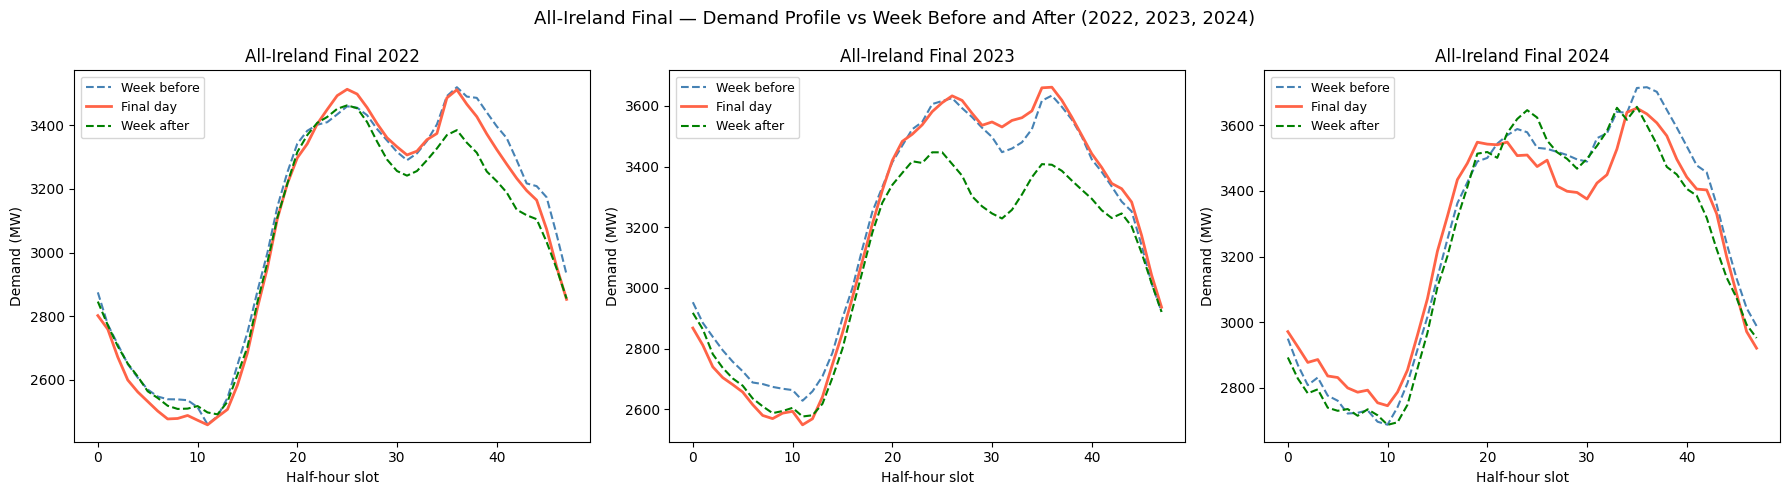

In [ ]:
# Chart 7 — Plotting the All-Ireland Final demand profile across all 3 years to show the event-driven demand pattern is consistent and repeatable

events_by_year = {
    "All-Ireland Final 2022" : "2022-07-24",
    "All-Ireland Final 2023" : "2023-07-30",
    "All-Ireland Final 2024" : "2024-07-28",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (event_name, event_date) in zip(axes, events_by_year.items()):

    event_dt    = pd.Timestamp(event_date)
    week_before = event_dt - pd.Timedelta(days=7)
    week_after  = event_dt + pd.Timedelta(days=7)

    before_data = df[df.index.date == week_before.date()]['demand_mw'].values
    event_data  = df[df.index.date == event_dt.date()]['demand_mw'].values
    after_data  = df[df.index.date == week_after.date()]['demand_mw'].values

    if len(before_data) == 48:
        ax.plot(range(48), before_data, color='steelblue',
                linestyle='--', linewidth=1.5, label='Week before')
    if len(event_data) == 48:
        ax.plot(range(48), event_data, color='tomato',
                linestyle='-', linewidth=2, label='Final day')
    if len(after_data) == 48:
        ax.plot(range(48), after_data, color='green',
                linestyle='--', linewidth=1.5, label='Week after')

    ax.set_title(event_name)
    ax.set_xlabel('Half-hour slot')
    ax.set_ylabel('Demand (MW)')
    ax.legend(fontsize=9)

plt.suptitle('All-Ireland Final — Demand Profile vs Week Before and After (2022, 2023, 2024)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/chart7_allirefinal_all_years.png', dpi=150)
plt.show()


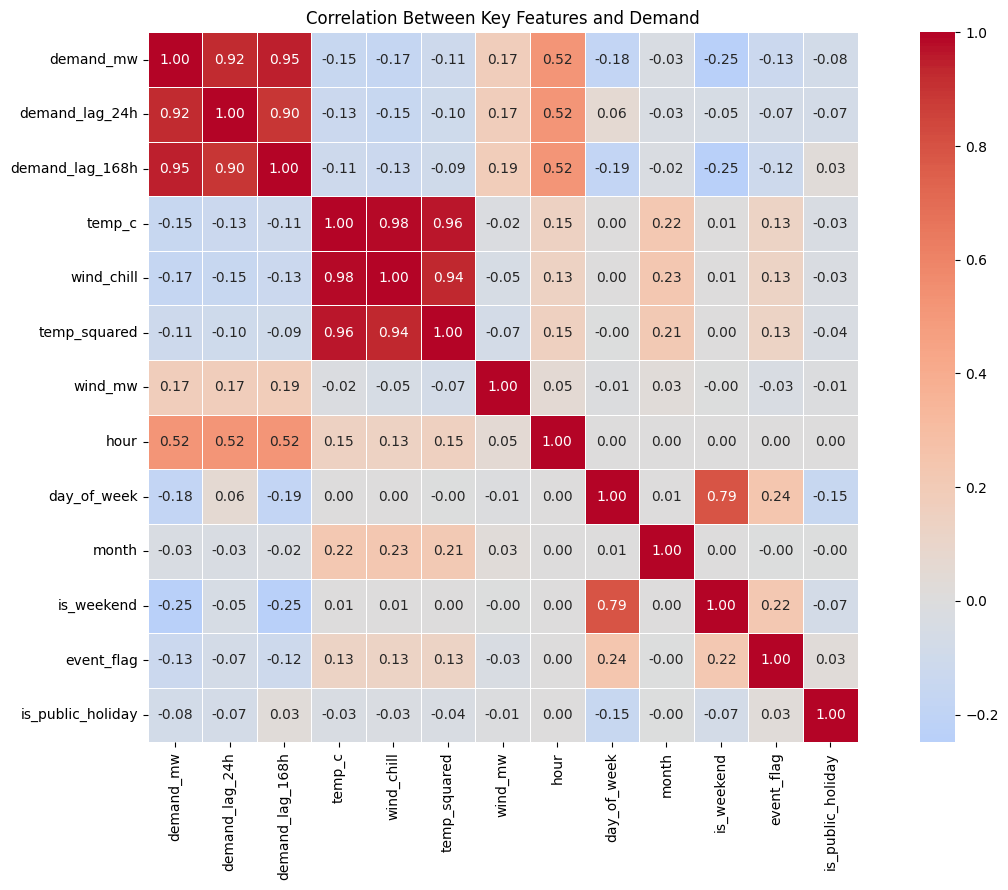

In [ ]:
# Chart 8 — Checking how strongly each feature is correlated with demand to validate the feature engineering decisions made in Step 1
features = [
    'demand_mw', 'demand_lag_24h', 'demand_lag_168h',
    'temp_c', 'wind_chill', 'temp_squared',
    'wind_mw', 'hour', 'day_of_week', 'month',
    'is_weekend', 'event_flag', 'is_public_holiday'
]

corr_matrix = df[features].dropna().corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Between Key Features and Demand')
plt.tight_layout()
plt.savefig('/content/chart8_correlation.png', dpi=150)
plt.show()


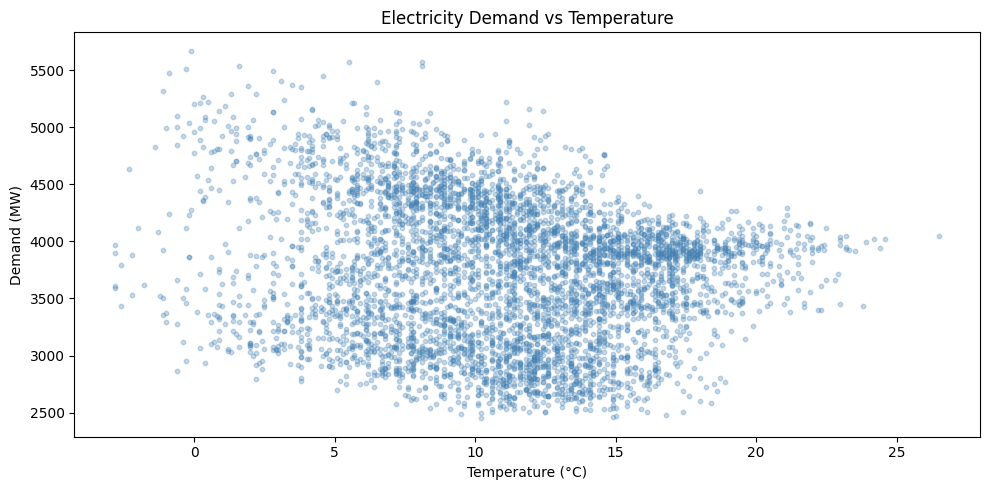

In [ ]:
# Chart 9 — Scatter plot of demand against temperature to confirm the non-linear relationship between cold weather and electricity consumption
sample = df[['temp_c', 'demand_mw']].dropna().sample(5000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['temp_c'], sample['demand_mw'],
            alpha=0.3, color='steelblue', s=10)
plt.title('Electricity Demand vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('/content/chart9_demand_vs_temp.png', dpi=150)
plt.show()


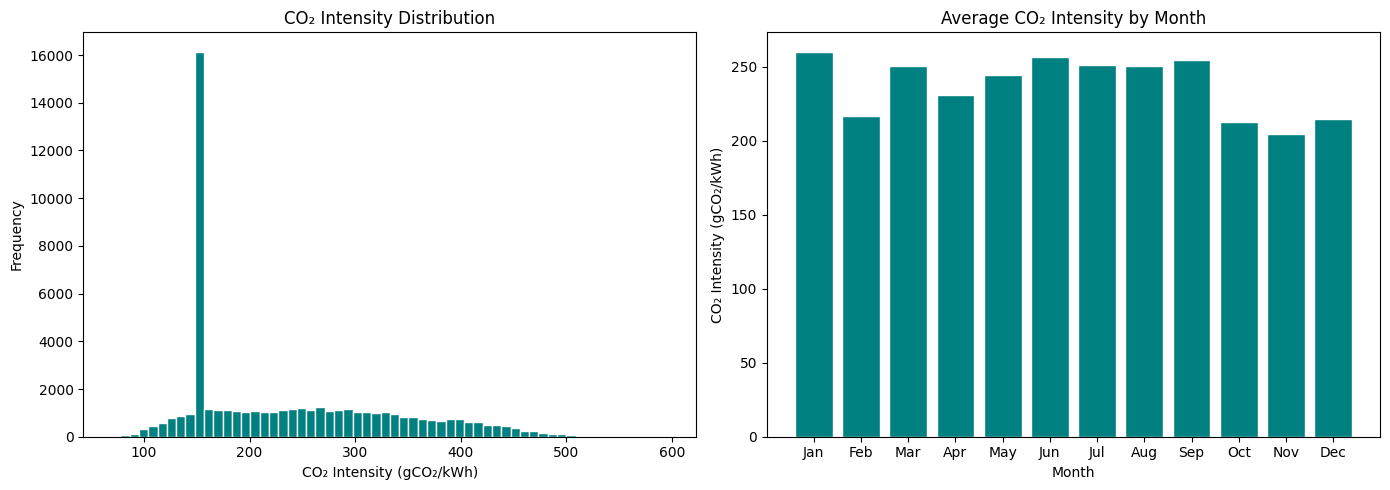

In [ ]:
# Chart 10 — Plotting the distribution of CO2 intensity and its monthly average to understand when the grid is cleanest and most carbon intensive
co2_data = df['co2_intensity'].dropna()
co2_by_month = df.groupby('month')['co2_intensity'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(co2_data, bins=60, color='teal', edgecolor='white')
axes[0].set_title('CO₂ Intensity Distribution')
axes[0].set_xlabel('CO₂ Intensity (gCO₂/kWh)')
axes[0].set_ylabel('Frequency')

axes[1].bar(month_names, co2_by_month.values, color='teal', edgecolor='white')
axes[1].set_title('Average CO₂ Intensity by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('CO₂ Intensity (gCO₂/kWh)')

plt.tight_layout()
plt.savefig('/content/chart10_co2_intensity.png', dpi=150)
plt.show()



In [ ]:
import os

charts = [f for f in os.listdir('/content') if f.endswith('.png')]
charts.sort()

print(f"Total charts saved: {len(charts)}")
print()
for chart in charts:
    print(chart)

Total charts saved: 10

chart10_co2_intensity.png
chart1_overall_trend.png
chart2_load_curve.png
chart3_demand_by_dow.png
chart4_demand_by_month.png
chart5_event_vs_nonevent.png
chart6_top10_days.png
chart7_allirefinal_all_years.png
chart8_correlation.png
chart9_demand_vs_temp.png
